In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
DATA_DIR = Path("data")
RAW_DATA_DIR = DATA_DIR / "raw"
FIGURES_DIR = Path("figures")
REPORTS_DIR = Path("reports")

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)



In [11]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
raw_file = RAW_DATA_DIR / "penguins.csv"

if not raw_file.exists():
    df = pd.read_csv(url)
    df.to_csv(raw_file, index=False)
else:
    df = pd.read_csv(raw_file)

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [12]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [13]:
df.sample(5, random_state=42)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
194,Chinstrap,Dream,50.9,19.1,196.0,3550.0,MALE
157,Chinstrap,Dream,45.2,17.8,198.0,3950.0,FEMALE
225,Gentoo,Biscoe,46.5,13.5,210.0,4550.0,FEMALE
208,Chinstrap,Dream,45.2,16.6,191.0,3250.0,FEMALE
318,Gentoo,Biscoe,48.4,14.4,203.0,4625.0,FEMALE


In [14]:
df.shape

(344, 7)

In [15]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [17]:
df.dtypes

,0
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object


In [18]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


1. one row represents onepenguin.
2. Numerical : bill_lenth_mm, bill_depth_mm, flipper_length_mm,body_mass_g. categorical : speies, island, sex.
3. The target would be species.
4.I noticed that some columns contain missing values.


In [19]:
missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100,
})

missing_report

,missing_count,missing_percentage
species,0,0.000000
island,0,0.000000
bill_length_mm,2,0.581395
bill_depth_mm,2,0.581395
flipper_length_mm,2,0.581395
body_mass_g,2,0.581395
sex,11,3.197674


**1. Which columns contain missing values?**

The columns with missing values are bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g, and sex.


In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.nunique()

,0
species,3
island,3
bill_length_mm,164
bill_depth_mm,80
flipper_length_mm,55
body_mass_g,94
sex,2


### 2. What did you notice about the number of unique values?

The categorical columns have a small number of unique values. Species and island each have 3 unique values, while sex has 2 unique values. The numerical columns have more unique values.


 3. Data Quality Decision
 The dataset contains some missing values, but there are no duplicate rows.I will not remove or modify the missing values at this stage because the assigmnent asks for a data _quality audit before makingany cleaning decisions.



What does the distribution of penguin body mass look like?

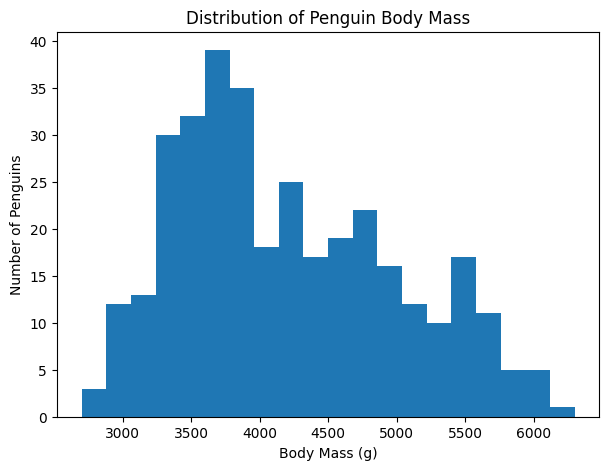

In [22]:
plt.figure(figsize=(7, 5))

plt.hist(df["body_mass_g"].dropna(), bins=20)

plt.title("Distribution of Penguin Body Mass")
plt.xlabel("Body Mass (g)")
plt.ylabel("Number of Penguins")

plt.savefig(FIGURES_DIR / "body_mass_histogram.png")

plt.show()

The body mass values are spread aceoss arangeof weights with most penguins concentrated in the middle of the distribution.


Are there any statistically unusual body mass values?

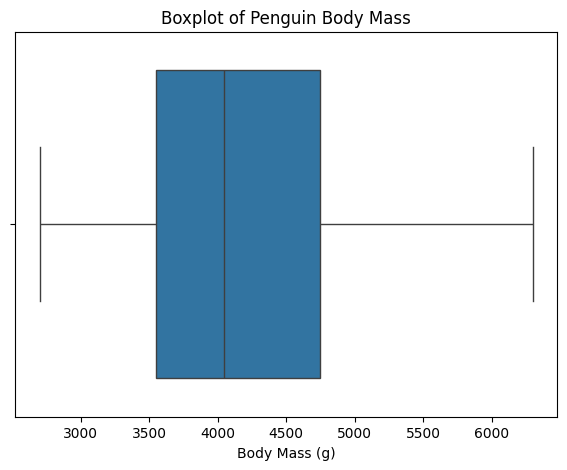

In [23]:
plt.figure(figsize=(7, 5))

sns.boxplot(x=df["body_mass_g"])

plt.title("Boxplot of Penguin Body Mass")
plt.xlabel("Body Mass (g)")

plt.savefig(FIGURES_DIR / "body_mass_boxplot.png")

plt.show()

In [24]:
q1 = df["body_mass_g"].dropna().quantile(0.25)
q3 = df["body_mass_g"].dropna().quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

q1, q3, iqr, lower_bound, upper_bound

(np.float64(3550.0),
 np.float64(4750.0),
 np.float64(1200.0),
 np.float64(1750.0),
 np.float64(6550.0))

In [25]:
outliers = df[
    (df["body_mass_g"] < lower_bound) |
    (df["body_mass_g"] > upper_bound)
]

outliers[["species", "island", "body_mass_g"]]

,species,island,body_mass_g



The first quartile (Q1) is 3550 g and the third quartile (Q3) is 4750 g. The IQR is 1200 g, giving lower and upper bounds of 1750 g and 6550 g. I will not automatically remove observations outside these bounds because statistically unusual values are not necessarily invalid.


Is flipper length related to body mass, and does the pattern differ across species?


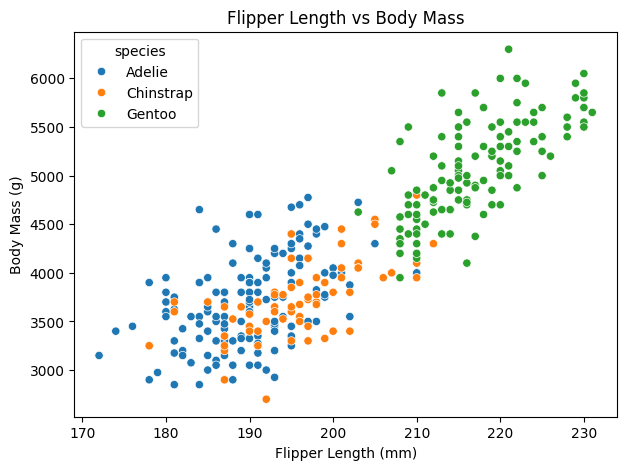

In [26]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species"
)

plt.title("Flipper Length vs Body Mass")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")

plt.savefig(FIGURES_DIR / "flipper_vs_body_mass.png")

plt.show()

Do penguin species differ in average body mass?


In [27]:
species_mass = df.groupby("species")["body_mass_g"].mean()

species_mass

,body_mass_g
species,
Adelie,3700.662252
Chinstrap,3733.088235
Gentoo,5076.016260


**Evidence:** The average body mass is about 3701 g for Adelie, 3733 g for Chinstrap, and 5076 g for Gentoo.

**Insight:** Gentoo penguins have a much higher average body mass than the other two species.

**Limit:** This is a descriptive comparison and does not explain why the species differ.


Is flipper length related to body mass?


In [28]:
df[["flipper_length_mm", "body_mass_g"]].corr()

,flipper_length_mm,body_mass_g
flipper_length_mm,1.000000,0.871202
body_mass_g,0.871202,1.000000


**Evidence:** The correlation between flipper length and body mass is about 0.87.

**Insight:** This indicates a strong positive relationship between flipper length and body mass.

**Limit:** Correlation does not prove that one variable causes the other.


Does that relationship look different across species?


**Evidence:** The scatter plot shows a positive relationship between flipper length and body mass, while the species form separate groups with different ranges of values.

**Insight:** The relationship appears different across species because each species occupies a different range of flipper lengths and body masses.

**Limit:** This is a visual descriptive observation and no statistical test was performed to compare the relationships between species.


Which islands contain which species?


In [29]:
pd.crosstab(df["island"], df["species"])

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,124
Dream,56,68,0
Torgersen,52,0,0


**Evidence:** Torgersen contains Adelie penguins only. Dream contains Adelie and Chinstrap penguins. Biscoe contains Adelie and Gentoo penguins.

**Insight:** The species are not distributed equally across the three islands.

**Limit:** This describes the distribution in this dataset and does not explain why the species are associated with particular islands.


Do male and female penguins appear to differ in body mass?


In [30]:
df.groupby("sex")["body_mass_g"].mean()

,body_mass_g
sex,
FEMALE,3862.272727
MALE,4545.684524


**Evidence:** The average body mass is about 3862 g for females and 4546 g for males.

**Insight:** Male penguins have a higher average body mass than female penguins in this dataset.

**Limit:** This is a descriptive comparison and does not establish a causal relationship.


In [31]:
def missing_value_report(dataframe: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "missing_count": dataframe.isna().sum(),
        "missing_percentage": dataframe.isna().mean() * 100
    })

In [32]:
missing_value_report(df)

,missing_count,missing_percentage
species,0,0.000000
island,0,0.000000
bill_length_mm,2,0.581395
bill_depth_mm,2,0.581395
flipper_length_mm,2,0.581395
body_mass_g,2,0.581395
sex,11,3.197674


In [33]:
def audit_dataframe(dataframe: pd.DataFrame) -> dict:
    return {
        "rows": dataframe.shape[0],
        "columns": dataframe.shape[1],
        "duplicates": dataframe.duplicated().sum(),
        "total_missing_values": dataframe.isna().sum().sum(),
        "numerical_columns": dataframe.select_dtypes(include=np.number).columns.tolist(),
        "categorical_columns": dataframe.select_dtypes(exclude=np.number).columns.tolist()
    }

In [34]:
audit = audit_dataframe(df)

audit

{'rows': 344,
 'columns': 7,
 'duplicates': np.int64(0),
 'total_missing_values': np.int64(19),
 'numerical_columns': ['bill_length_mm',
  'bill_depth_mm',
  'flipper_length_mm',
  'body_mass_g'],
 'categorical_columns': ['species', 'island', 'sex']}

In [35]:
pd.DataFrame([audit]).to_csv(
    REPORTS_DIR / "data_quality_summary.csv",
    index=False
)

In [36]:
pd.read_csv(REPORTS_DIR / "data_quality_summary.csv")

,rows,columns,duplicates,total_missing_values,numerical_columns,categorical_columns
0,344,7,0,19,"['bill_length_mm', 'bill_depth_mm', 'flipper_l...","['species', 'island', 'sex']"


In [37]:
list(FIGURES_DIR.iterdir())

[PosixPath('figures/body_mass_boxplot.png'),
 PosixPath('figures/body_mass_histogram.png'),
 PosixPath('figures/flipper_vs_body_mass.png')]

In [38]:
readme_content = """
# Session 02 - Data Workflow

## Project Overview

This project focuses on inspecting, exploring, and auditing the Palmer Penguins dataset before any modeling.

The goal is to understand the structure of the data, identify data quality issues, explore relationships between variables, and document the findings in a reproducible workflow.

## Dataset

The dataset used in this project is the Palmer Penguins dataset.

It contains information about penguin species, islands, body measurements, and sex.

## Questions Investigated

1. Do penguin species differ in average body mass?
2. Is flipper length related to body mass?
3. Does the relationship between flipper length and body mass look different across species?
4. Which islands contain which species?
5. Do male and female penguins appear to differ in body mass?

## Key Findings

- Gentoo penguins have a higher average body mass than Adelie and Chinstrap penguins in this dataset.
- Flipper length and body mass show a strong positive correlation.
- The species form different groups in the relationship between flipper length and body mass.
- Species are not distributed equally across the three islands.
- Male penguins have a higher average body mass than female penguins in this dataset.

## Data Quality Issues

- The dataset contains missing values in some numerical columns and in the sex column.
- There are no duplicate rows.
- IQR analysis did not identify body mass values outside the statistical bounds.
- Missing values and unusual values were not automatically removed or changed.

## How to Run

1. Open the notebook in the `notebooks` folder.
2. Make sure the required Python libraries are installed.
3. Run the notebook from top to bottom.

## Limitations

This project is a descriptive data analysis and data quality audit. No predictive model was trained.

The findings describe patterns in this dataset and do not establish causal relationships.

## Next Step

The next step would be to clean and prepare the data carefully before applying a machine learning model.
"""

readme_path = Path("README.md")
readme_path.write_text(readme_content.strip(), encoding="utf-8")

print("README.md created successfully.")

README.md created successfully.


In [39]:
requirements_content = """
numpy
pandas
matplotlib
seaborn
"""

requirements_path = Path("requirements.txt")
requirements_path.write_text(requirements_content.strip(), encoding="utf-8")

print("requirements.txt created successfully.")


requirements.txt created successfully.


In [40]:
gitignore_content = """
__pycache__/
.ipynb_checkpoints/
.env
"""

gitignore_path = Path(".gitignore")
gitignore_path.write_text(gitignore_content.strip(), encoding="utf-8")

print(".gitignore created successfully.")

.gitignore created successfully.


In [41]:
print("README.md:", Path("README.md").exists())
print("requirements.txt:", Path("requirements.txt").exists())
print(".gitignore:", Path(".gitignore").exists())

README.md: True
requirements.txt: True
.gitignore: True


In [42]:
from pathlib import Path

print("Project files:")
for path in Path(".").iterdir():
    print(path)

Project files:
.config
data
figures
README.md
.gitignore
reports
requirements.txt
sample_data


In [43]:
print("Dataset:")
print((Path("data") / "raw" / "penguins.csv").exists())

print("\nFigures:")
for file in Path("figures").iterdir():
    print(file.name)

print("\nReport:")
print((Path("reports") / "data_quality_summary.csv").exists())

Dataset:
True

Figures:
body_mass_boxplot.png
body_mass_histogram.png
flipper_vs_body_mass.png

Report:
True
